# 18 - CNN VGG-like con BatchNorm, augmentation suave y TTA

Evolucion de la rama CNN del `10`: en vez de usar `VGG16(weights=None)` directamente, se construye una VGG-like desde cero con `BatchNormalization`, regularizacion moderada, augmentation suave y seleccion automatica de TTA segun validacion. El objetivo es mejorar la CNN scratch sin usar transfer learning.

## Librerias y configuracion


In [1]:
import json
import time
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RUN_START = time.perf_counter()

gpus = tf.config.list_physical_devices('GPU')
print('GPUs disponibles:', gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print('No se pudo activar memory_growth:', exc)


2026-06-09 08:35:07.512338: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780994107.910098      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780994108.024649      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780994108.969270      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780994108.969312      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780994108.969315      58 computation_placer.cc:177] computation placer alr

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
SEED = 42
BATCH_SIZE = 24
EPOCHS = 90
VALIDATION_SIZE = 0.15
IMAGE_SHAPE = (224, 224, 3)

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.02

USE_MIXED_PRECISION = True
USE_TTA_VALIDATION = True
USE_TTA_CODABENCH = True
TTA_BATCH_SIZE = 48

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

if USE_MIXED_PRECISION and gpus:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

print('Politica de precision:', tf.keras.mixed_precision.global_policy())


Politica de precision: <DTypePolicy "mixed_float16">


## Datos


### Localizacion de inputs


In [3]:
KAGGLE_INPUT_DIR = Path('/kaggle/input')
WORKDIR = Path('/kaggle/working')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError('No existe /kaggle/input. Ejecuta este notebook en Kaggle.')

array_dirs = sorted({p.parent for p in KAGGLE_INPUT_DIR.rglob('X_all.npy')})
if not array_dirs:
    raise FileNotFoundError('No se encontro X_all.npy. Anade el dataset xview_arrays como Input.')

ARRAYS_DIR = array_dirs[0]

ann_candidates = sorted(
    p for p in KAGGLE_INPUT_DIR.rglob('xview_ann_train.json')
    if (p.parent / 'xview_test').exists()
)
if not ann_candidates:
    raise FileNotFoundError('No se encontro xview_ann_train.json con carpeta xview_test al lado. Anade xview_recognition como Input.')

ANN_JSON = ann_candidates[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'

print('ARRAYS_DIR:', ARRAYS_DIR)
print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


ARRAYS_DIR: /kaggle/input/datasets/eduardocama/xview-array/xview_arrays
DATA_ROOT: /kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition
ANN_JSON: /kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


### Lectura de arrays


In [4]:
DATA_LOAD_START = time.perf_counter()

X_all = np.load(ARRAYS_DIR / 'X_all.npy')
y_all_idx = np.load(ARRAYS_DIR / 'y_all_idx.npy')
filenames = np.load(ARRAYS_DIR / 'filenames.npy').astype(str)
image_ids = np.load(ARRAYS_DIR / 'image_ids.npy').astype(str)
category_names = np.load(ARRAYS_DIR / 'category_names.npy').astype(str).tolist()

metadata_path = ARRAYS_DIR / 'metadata.json'
if metadata_path.exists():
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
else:
    metadata = {}

num_classes = len(category_names)

print('X_all:', X_all.shape, X_all.dtype, 'RAM aprox:', X_all.nbytes / 1024**3, 'GB')
print('y_all_idx:', y_all_idx.shape, y_all_idx.dtype)
print('filenames:', filenames.shape)
print('image_ids:', image_ids.shape)
print('num_classes:', num_classes)
print('category_names:', category_names)
print('metadata:', metadata)


X_all: (18746, 224, 224, 3) uint8 RAM aprox: 2.6280040740966797 GB
y_all_idx: (18746,) int32
filenames: (18746,)
image_ids: (18746,)
num_classes: 13
category_names: ['Cargo plane', 'Small car', 'Bus', 'Truck', 'Motorboat', 'Fishing vessel', 'Dump truck', 'Excavator', 'Building', 'Helipad', 'Storage tank', 'Shipping container', 'Pylon']
metadata: {'num_images': 18746, 'image_shape': [224, 224, 3], 'x_dtype': 'uint8', 'y_dtype': 'int32', 'category_names': ['Cargo plane', 'Small car', 'Bus', 'Truck', 'Motorboat', 'Fishing vessel', 'Dump truck', 'Excavator', 'Building', 'Helipad', 'Storage tank', 'Shipping container', 'Pylon'], 'category_to_idx': {'Cargo plane': 0, 'Small car': 1, 'Bus': 2, 'Truck': 3, 'Motorboat': 4, 'Fishing vessel': 5, 'Dump truck': 6, 'Excavator': 7, 'Building': 8, 'Helipad': 9, 'Storage tank': 10, 'Shipping container': 11, 'Pylon': 12}, 'source_ann_json': '/kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition/xview_ann_train.json'}


### Comprobacion de una imagen


filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
image_id: 0234476c-a017-4c9b-bd2f-872193076cca.tif
label idx: 8
label name: Building
shape: (224, 224, 3) dtype: uint8
Primeros pixeles del array:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]


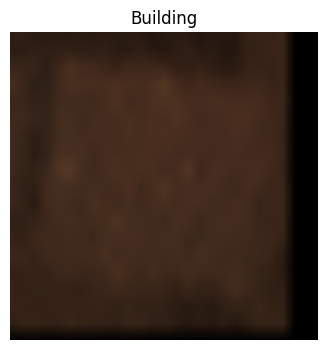

In [5]:
sample_idx = 0
sample_image = X_all[sample_idx]
sample_label_idx = int(y_all_idx[sample_idx])

print('filename:', filenames[sample_idx])
print('image_id:', image_ids[sample_idx])
print('label idx:', sample_label_idx)
print('label name:', category_names[sample_label_idx])
print('shape:', sample_image.shape, 'dtype:', sample_image.dtype)
print('Primeros pixeles del array:')
print(sample_image[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(category_names[sample_label_idx])
plt.axis('off')
plt.show()


### Split train/valid


In [6]:
indices = np.arange(len(X_all))
train_idx, val_idx = train_test_split(
    indices,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=y_all_idx,
)

X_train = X_all[train_idx]
X_valid = X_all[val_idx]
y_train_idx = y_all_idx[train_idx]
y_valid_idx = y_all_idx[val_idx]

y_train = tf.keras.utils.to_categorical(y_train_idx, num_classes=num_classes).astype(np.float32)
y_valid = tf.keras.utils.to_categorical(y_valid_idx, num_classes=num_classes).astype(np.float32)

DATA_LOAD_TIME = time.perf_counter() - DATA_LOAD_START

print('X_train:', X_train.shape, X_train.dtype, 'RAM aprox:', X_train.nbytes / 1024**3, 'GB')
print('X_valid:', X_valid.shape, X_valid.dtype, 'RAM aprox:', X_valid.nbytes / 1024**3, 'GB')
print('y_train:', y_train.shape, y_train.dtype)
print('y_valid:', y_valid.shape, y_valid.dtype)
print(f'Tiempo carga arrays/split: {DATA_LOAD_TIME:.2f} s')


X_train: (15934, 224, 224, 3) uint8 RAM aprox: 2.2337894439697266 GB
X_valid: (2812, 224, 224, 3) uint8 RAM aprox: 0.3942146301269531 GB
y_train: (15934, 13) float32
y_valid: (2812, 13) float32
Tiempo carga arrays/split: 17.56 s


## Red


### Augmentation suave


In [7]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.05, fill_mode='reflect', seed=SEED + 1),
    tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode='reflect', seed=SEED + 2),
    tf.keras.layers.RandomZoom(0.04, fill_mode='reflect', seed=SEED + 3),
], name='augmentation_suave')


I0000 00:00:1780994177.917756      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780994177.923776      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### Modelo VGG-like con BatchNorm


In [8]:
def conv_bn_relu(x, filters, block, conv):
    x = tf.keras.layers.Conv2D(
        filters,
        kernel_size=3,
        padding='same',
        use_bias=False,
        kernel_initializer=tf.keras.initializers.HeNormal(seed=SEED + block * 10 + conv),
        kernel_regularizer=tf.keras.regularizers.l2(WEIGHT_DECAY),
        name=f'block{block}_conv{conv}',
    )(x)
    x = tf.keras.layers.BatchNormalization(name=f'block{block}_bn{conv}')(x)
    x = tf.keras.layers.Activation('relu', name=f'block{block}_relu{conv}')(x)
    return x


def vgg_block(x, filters, convs, dropout, block):
    for conv in range(1, convs + 1):
        x = conv_bn_relu(x, filters, block, conv)
    x = tf.keras.layers.MaxPooling2D(pool_size=2, name=f'block{block}_pool')(x)
    if dropout > 0:
        x = tf.keras.layers.SpatialDropout2D(dropout, name=f'block{block}_spatial_dropout')(x)
    return x


inputs = tf.keras.Input(shape=IMAGE_SHAPE, name='image')
x = tf.keras.layers.Rescaling(1.0 / 255.0, name='rescaling')(inputs)
x = data_aug(x)

x = vgg_block(x, filters=64, convs=2, dropout=0.05, block=1)
x = vgg_block(x, filters=128, convs=2, dropout=0.10, block=2)
x = vgg_block(x, filters=256, convs=3, dropout=0.15, block=3)
x = vgg_block(x, filters=512, convs=3, dropout=0.20, block=4)
x = vgg_block(x, filters=512, convs=3, dropout=0.25, block=5)

gap = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
gmp = tf.keras.layers.GlobalMaxPooling2D(name='gmp')(x)
x = tf.keras.layers.Concatenate(name='gap_gmp')([gap, gmp])
x = tf.keras.layers.BatchNormalization(name='head_bn_1')(x)
x = tf.keras.layers.Dropout(0.45, name='head_dropout_1')(x)
x = tf.keras.layers.Dense(
    512,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(WEIGHT_DECAY),
    name='head_dense',
)(x)
x = tf.keras.layers.BatchNormalization(name='head_bn_2')(x)
x = tf.keras.layers.Dropout(0.45, name='head_dropout_2')(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32', name='predictions')(x)

model = tf.keras.Model(inputs, outputs, name='cnn_vgg_bn_aug_tta')
model.summary()


Model: "cnn_vgg_bn_aug_tta"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation_suave  │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,728 │ augmentation_sua… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn1          │ (None, 224, 224,  │        256 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_relu1        │ (None, 224, 224,  │          0 │ block1_bn1[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,864 │ block1_relu1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn2          │ (None, 224, 224,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_relu2        │ (None, 224, 224,  │          0 │ block1_bn2[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_relu2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_spatial_dro… │ (None, 112, 112,  │          0 │ block1_pool[0][0] │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,728 │ block1_spatial_d… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn1          │ (None, 112, 112,  │        512 │ block2_conv1[0][… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_relu1        │ (None, 112, 112,  │          0 │ block2_bn1[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,456 │ block2_relu1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn2          │ (None, 112, 112,  │        512 │ block2_conv2[0][… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_relu2        │ (None, 112, 112,  │          0 │ block2_bn2[0][0]

 Total params: 15,264,973 (58.23 MB)

 Trainable params: 15,253,453 (58.19 MB)

 Non-trainable params: 11,520 (45.00 KB)

### Callbacks


In [9]:
def make_optimizer():
    try:
        return tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    except Exception:
        print('AdamW no disponible; usando Adam.')
        return tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)


MODEL_PATH = WORKDIR / '18_cnn_vgg_bn_aug_tta.weights.h5'

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

model.compile(
    optimizer=make_optimizer(),
    loss=loss_fn,
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_PATH),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

print('Modelo guardado en:', MODEL_PATH)


Modelo guardado en: /kaggle/working/18_cnn_vgg_bn_aug_tta.weights.h5


### Entrenamiento


In [10]:
TRAIN_START = time.perf_counter()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

TRAIN_TIME = time.perf_counter() - TRAIN_START

best_idx = int(np.argmax(history.history['val_accuracy']))
best_value = float(np.max(history.history['val_accuracy']))
print('Best validation model: epoch', best_idx + 1, '- val_accuracy', best_value)
print(f'Tiempo entrenamiento: {TRAIN_TIME:.2f} s')


Epoch 1/90


I0000 00:00:1780994197.679846     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.1911 - loss: 3.9680
Epoch 1: val_accuracy improved from None to 0.34104, saving model to /kaggle/working/18_cnn_vgg_bn_aug_tta.weights.h5

Epoch 1: finished saving model to /kaggle/working/18_cnn_vgg_bn_aug_tta.weights.h5
664/664 ━━━━━━━━━━━━━━━━━━━━ 342s 454ms/step - accuracy: 0.2348 - loss: 3.6340 - val_accuracy: 0.3410 - val_loss: 2.9371 - learning_rate: 3.0000e-04
Epoch 2/90
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.3190 - loss: 3.1141
Epoch 2: val_accuracy improved from 0.34104 to 0.44061, saving model to /kaggle/working/18_cnn_vgg_bn_aug_tta.weights.h5

Epoch 2: finished saving model to /kaggle/working/18_cnn_vgg_bn_aug_tta.weights.h5
664/664 ━━━━━━━━━━━━━━━━━━━━ 276s 415ms/step - accuracy: 0.3339 - loss: 3.0262 - val_accuracy: 0.4406 - val_loss: 2.6835 - learning_rate: 3.0000e-04
Epoch 3/90
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.3696 - loss: 2.8386
Epoch 3: val_accuracy improved from 0.4406

## Resultados


### Graficas


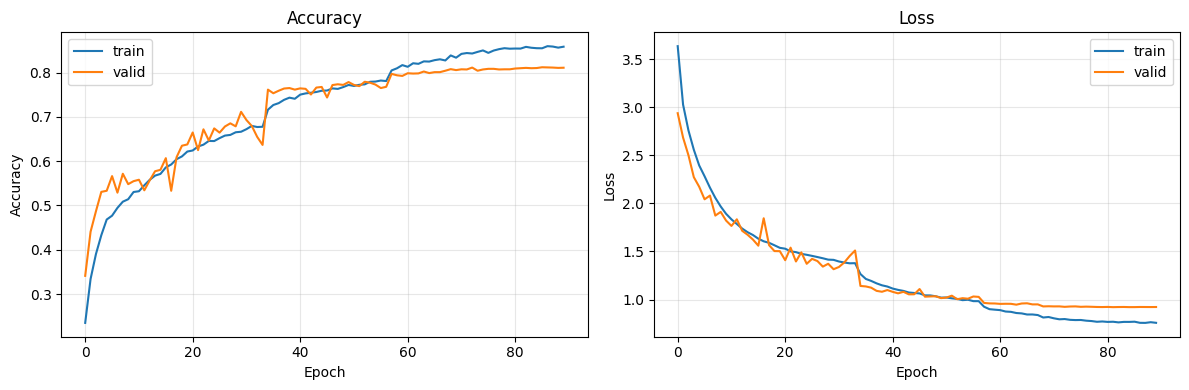

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='valid')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='valid')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Predicciones de validacion


In [12]:
def predict_with_tta_array(model, images, batch_size=64, use_tta=True, verbose=0):
    variants = [('identity', images)]
    if use_tta:
        variants.extend([
            ('hflip', np.flip(images, axis=2)),
            ('vflip', np.flip(images, axis=1)),
            ('rot90', np.rot90(images, k=1, axes=(1, 2))),
            ('rot180', np.rot90(images, k=2, axes=(1, 2))),
            ('rot270', np.rot90(images, k=3, axes=(1, 2))),
        ])

    probs_sum = None
    for name, variant in variants:
        variant = np.ascontiguousarray(variant)
        probs = model.predict(variant, batch_size=batch_size, verbose=verbose)
        probs_sum = probs if probs_sum is None else probs_sum + probs
        print('TTA variant procesada:', name)

    return probs_sum / len(variants)


model.load_weights(MODEL_PATH)

valid_loss, valid_accuracy = model.evaluate(X_valid, y_valid, batch_size=BATCH_SIZE, verbose=1)
print('Validation loss normal:', valid_loss)
print('Validation accuracy normal:', valid_accuracy)

plain_probs = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=1)
plain_pred_idx = np.argmax(plain_probs, axis=1)
plain_accuracy = accuracy_score(y_valid_idx, plain_pred_idx)
print('Plain validation accuracy:', plain_accuracy)

if USE_TTA_VALIDATION:
    tta_probs = predict_with_tta_array(model, X_valid, batch_size=TTA_BATCH_SIZE, use_tta=True, verbose=0)
    tta_pred_idx = np.argmax(tta_probs, axis=1)
    tta_accuracy = accuracy_score(y_valid_idx, tta_pred_idx)
    print('TTA validation accuracy:', tta_accuracy)

    if tta_accuracy >= plain_accuracy:
        probs = tta_probs
        y_pred_idx = tta_pred_idx
        PREDICTION_MODE = 'tta'
    else:
        probs = plain_probs
        y_pred_idx = plain_pred_idx
        PREDICTION_MODE = 'plain'
else:
    probs = plain_probs
    y_pred_idx = plain_pred_idx
    PREDICTION_MODE = 'plain'

y_true_idx = y_valid_idx
USE_TTA_CODABENCH_EFFECTIVE = bool(USE_TTA_CODABENCH and (PREDICTION_MODE == 'tta' or not USE_TTA_VALIDATION))

print('Modo usado para resultados:', PREDICTION_MODE)
print('TTA en Codabench:', USE_TTA_CODABENCH_EFFECTIVE)


118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.8119 - loss: 0.9209
Validation loss normal: 0.9209387898445129
Validation accuracy normal: 0.8118776679039001
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step
Plain validation accuracy: 0.811877667140825
TTA variant procesada: identity
TTA variant procesada: hflip
TTA variant procesada: vflip
TTA variant procesada: rot90
TTA variant procesada: rot180
TTA variant procesada: rot270
TTA validation accuracy: 0.8029871977240398
Modo usado para resultados: plain
TTA en Codabench: False


### Matriz de confusion


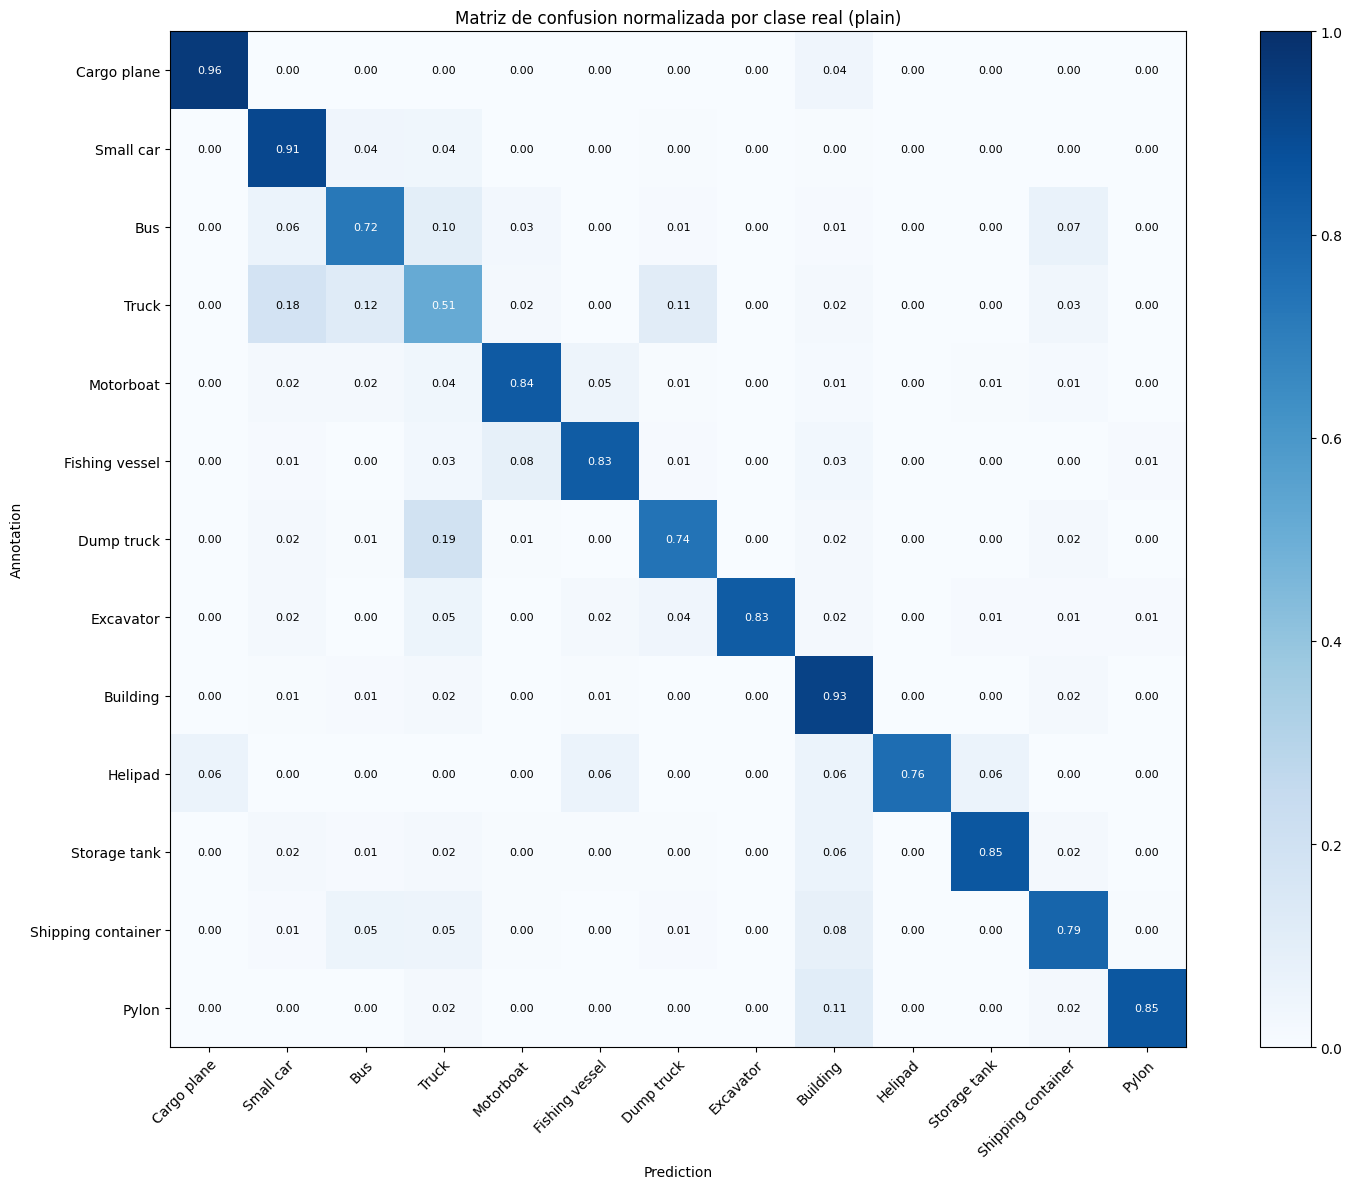

In [13]:
cm = confusion_matrix(y_true_idx, y_pred_idx, labels=np.arange(num_classes), normalize='true')

fig, ax = plt.subplots(figsize=(16, 12))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
fig.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(num_classes),
    yticks=np.arange(num_classes),
    xticklabels=category_names,
    yticklabels=category_names,
    ylabel='Annotation',
    xlabel='Prediction',
    title=f'Matriz de confusion normalizada por clase real ({PREDICTION_MODE})',
)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

for i in range(num_classes):
    for j in range(num_classes):
        value = cm[i, j]
        color = 'white' if value > 0.5 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()


### Metricas


In [14]:
print(classification_report(
    y_true_idx,
    y_pred_idx,
    labels=np.arange(num_classes),
    target_names=category_names,
    digits=4,
))


                    precision    recall  f1-score   support

       Cargo plane     0.9891    0.9579    0.9733        95
         Small car     0.8266    0.9078    0.8653       499
               Bus     0.6945    0.7208    0.7074       265
             Truck     0.5822    0.5120    0.5449       332
         Motorboat     0.8272    0.8375    0.8323       160
    Fishing vessel     0.8462    0.8302    0.8381       106
        Dump truck     0.7173    0.7405    0.7287       185
         Excavator     0.9800    0.8305    0.8991       118
          Building     0.8895    0.9258    0.9073       539
           Helipad     1.0000    0.7647    0.8667        17
      Storage tank     0.9689    0.8500    0.9056       220
Shipping container     0.7712    0.7948    0.7828       229
             Pylon     0.8889    0.8511    0.8696        47

          accuracy                         0.8119      2812
         macro avg     0.8447    0.8095    0.8247      2812
      weighted avg     0.8116    0.811

## Codabench


### Generacion del submission


In [15]:
CODABENCH_START = time.perf_counter()


def load_test_image(filename):
    return np.array(Image.open(DATA_ROOT / filename).convert('RGB'))


test_files = sorted(TEST_DIR.rglob('*.tif'))
print('Number of testing images:', len(test_files))
assert len(test_files) > 0, 'No se encontraron imagenes .tif en TEST_DIR.'

model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}
use_tta_codabench = globals().get('USE_TTA_CODABENCH_EFFECTIVE', USE_TTA_CODABENCH)
print('Usando TTA para Codabench:', use_tta_codabench)

batch_size = 64

for start in range(0, len(test_files), batch_size):
    batch_paths = test_files[start:start + batch_size]
    json_filenames = [path.relative_to(TEST_DIR).as_posix() for path in batch_paths]
    load_filenames = [path.relative_to(DATA_ROOT).as_posix() for path in batch_paths]

    images = np.stack([load_test_image(filename) for filename in load_filenames]).astype(np.uint8)
    probs_batch = predict_with_tta_array(
        model,
        images,
        batch_size=TTA_BATCH_SIZE,
        use_tta=use_tta_codabench,
        verbose=0,
    )
    pred_idx = np.argmax(probs_batch, axis=1)
    pred_scores = np.max(probs_batch, axis=1)

    for offset, (path, json_filename, cls_idx, score) in enumerate(zip(batch_paths, json_filenames, pred_idx, pred_scores)):
        idx = start + offset
        predictions_data['images'][idx] = {
            'image_id': path.name,
            'filename': json_filename,
            'width': 224,
            'height': 224,
        }
        predictions_data['annotations'][idx] = {
            'image_id': path.name,
            'category_id': category_names[int(cls_idx)],
            'score': float(score),
            'bbox': [0, 0, 224, 224],
        }

    print(f'Procesadas {min(start + batch_size, len(test_files))}/{len(test_files)}')

assert len(predictions_data['images']) == len(test_files)
assert len(predictions_data['annotations']) == len(test_files)

prediction_path = WORKDIR / 'prediction_18.json'
submission_path = WORKDIR / 'submission_18.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

CODABENCH_TIME = time.perf_counter() - CODABENCH_START

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')
print(f'Tiempo Codabench: {CODABENCH_TIME:.2f} s')

from IPython.display import FileLink, display
display(FileLink(str(submission_path)))


Number of testing images: 2365
Usando TTA para Codabench: False
TTA variant procesada: identity
Procesadas 64/2365
TTA variant procesada: identity
Procesadas 128/2365
TTA variant procesada: identity
Procesadas 192/2365
TTA variant procesada: identity
Procesadas 256/2365
TTA variant procesada: identity
Procesadas 320/2365
TTA variant procesada: identity
Procesadas 384/2365
TTA variant procesada: identity
Procesadas 448/2365
TTA variant procesada: identity
Procesadas 512/2365
TTA variant procesada: identity
Procesadas 576/2365
TTA variant procesada: identity
Procesadas 640/2365
TTA variant procesada: identity
Procesadas 704/2365
TTA variant procesada: identity
Procesadas 768/2365
TTA variant procesada: identity
Procesadas 832/2365
TTA variant procesada: identity
Procesadas 896/2365
TTA variant procesada: identity
Procesadas 960/2365
TTA variant procesada: identity
Procesadas 1024/2365
TTA variant procesada: identity
Procesadas 1088/2365
TTA variant procesada: identity
Procesadas 1152/236

/kaggle/working/submission_18.zip

### Resumen de tiempos


In [16]:
TOTAL_TIME = time.perf_counter() - RUN_START
print('Resumen de tiempos')
if 'DATA_LOAD_TIME' in globals():
    print(f'- Carga/preparacion de datos: {DATA_LOAD_TIME:.2f} s')
if 'TRAIN_TIME' in globals():
    print(f'- Entrenamiento: {TRAIN_TIME:.2f} s')
if 'CODABENCH_TIME' in globals():
    print(f'- Codabench: {CODABENCH_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME / 60:.2f} min')


Resumen de tiempos
- Carga/preparacion de datos: 17.56 s
- Entrenamiento: 24894.00 s
- Codabench: 47.55 s
- Tiempo total Run All: 25094.61 s
- Tiempo total Run All: 418.24 min
